In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as sla

## Eigenfaces

In [ ]:
from sklearn.datasets import fetch_lfw_people

In [ ]:
# Download the dataset

min_faces_per_person = 30

faces = fetch_lfw_people(min_faces_per_person=min_faces_per_person)

George W Bush


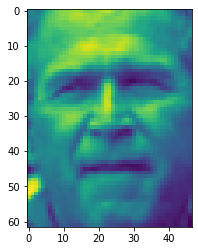

Arnold Schwarzenegger


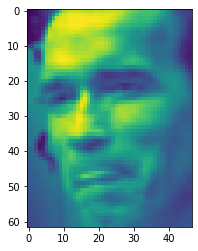

Laura Bush


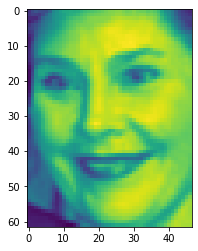

George W Bush


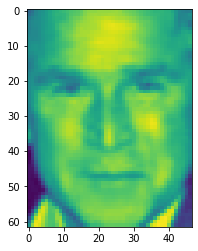

George W Bush


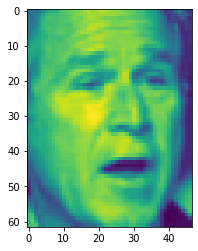

Nestor Kirchner


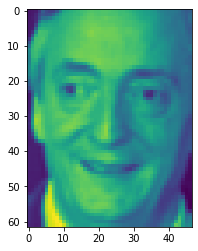

Arnold Schwarzenegger


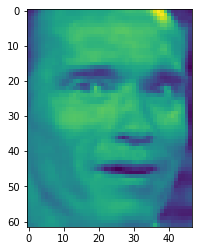

Lleyton Hewitt


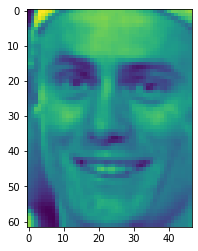

Colin Powell


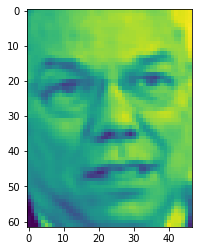

Lleyton Hewitt


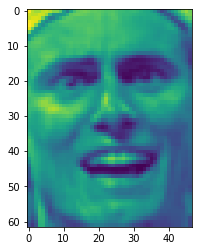

In [ ]:
# Print the first 10 faces with the corresponding names

for X, y in zip(faces.images[:10], faces.target[:10]):
    
    print(faces.target_names[y])
    plt.imshow(X)
    plt.show()

In [ ]:
print(faces.images.shape, faces.target_names.shape)

(2370, 62, 47) (34,)


In [ ]:
# Keep only 30 samples per each person

idx = np.zeros(faces.target.shape, dtype=bool) 

for name in range(len(faces.target_names)):

        idx[np.where(faces.target == name)[0][:min_faces_per_person]] = 1 # mask

X = faces.data[idx]
y = faces.target[idx]

# Normalize the data in [0,1]

X /= 255.

In [ ]:
X.shape

(1020, 2914)

In [ ]:
# Do PCA on the dataset using sklearn

from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X);

In [ ]:
pca.components_.shape

(1020, 2914)

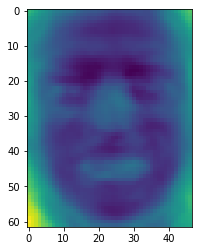

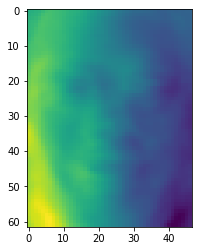

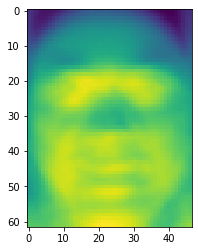

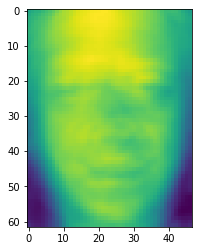

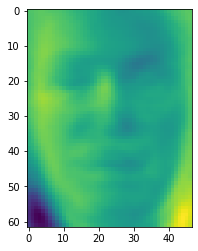

In [ ]:
# Plot the first 5 principal components

for i in range(5):
    
    plt.imshow(pca.components_[i].reshape(faces.images[0].shape))
    plt.show();

Text(0, 0.5, 'cumulative explained variance')

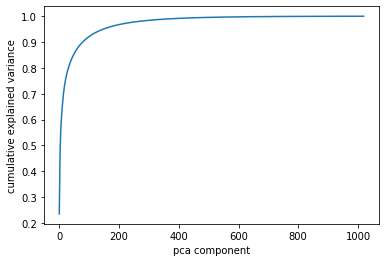

In [ ]:
# Plot the cumulative explained variance of the principal compoments

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("pca component")
plt.ylabel("cumulative explained variance")

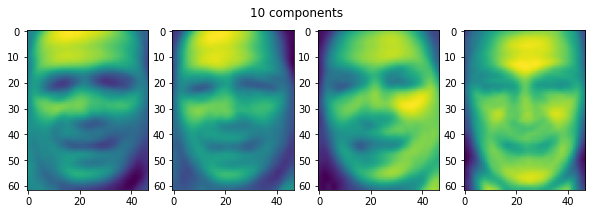

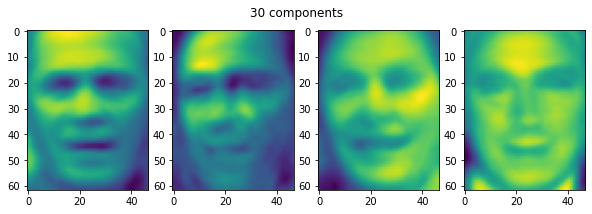

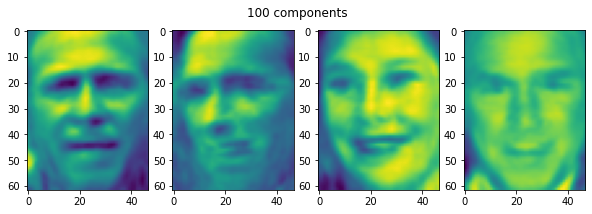

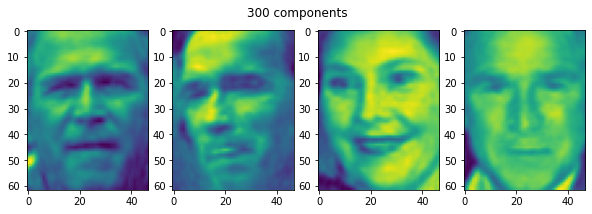

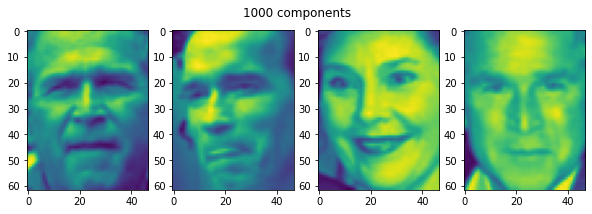

In [ ]:
# Plot the projections of 4 faces on the first {10, 30, 100, 300, 1000} 
# principal component

components = [10, 30, 100, 300, 1000]

for comp in components:

    pca = PCA(n_components=comp)
    pca.fit(X)
    X_transf = pca.inverse_transform(pca.transform(X[:4]))

    fig, ax = plt.subplots(1, 4, figsize=(10,3))
    fig.suptitle(f'{comp} components')
    for i in range(4):
        ax[i].imshow(X_transf[i].reshape(faces.images[0].shape))
    plt.show()

In [ ]:
# Train test split

from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(X, y)

In [ ]:
# Classify the faces with a 1-NN classifier

from sklearn.neighbors import KNeighborsClassifier

classifier = KNeighborsClassifier(n_neighbors=1)
classifier.fit(X_tr, y_tr)

print(classifier.score(X_te, y_te))

0.2549019607843137


In [ ]:
# Classify the faces using only the first 100 PCA projections

pca = PCA(n_components=100)
pca.fit(X_tr)

X_tr_pca = pca.transform(X_tr)

classifier = KNeighborsClassifier(n_neighbors=1)
classifier.fit(X_tr_pca, y_tr)

X_te_pca = pca.transform(X_te)

print(classifier.score(X_te_pca, y_te))

0.2784313725490196


In [ ]:
# Repeat adding whitening (rescale the variances to 1)

pca = PCA(n_components=100, whiten=True)
pca.fit(X_tr)

X_tr_pca = pca.transform(X_tr)

classifier = KNeighborsClassifier(n_neighbors=1)
classifier.fit(X_tr_pca, y_tr)

X_te_pca = pca.transform(X_te)

print(classifier.score(X_te_pca, y_te))

0.3411764705882353


## BBP Phase Transition in the Card Game

delta = 0.001


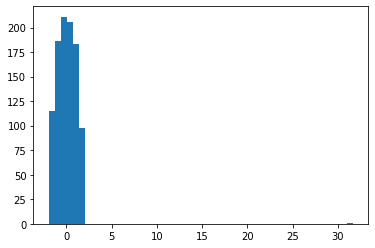

delta = 0.01


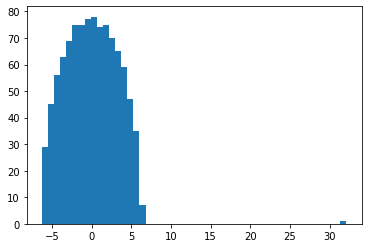

delta = 0.1


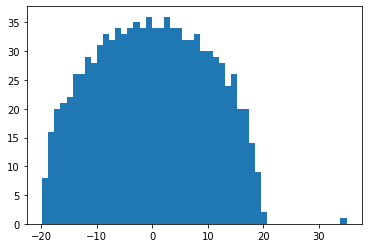

delta = 1.0


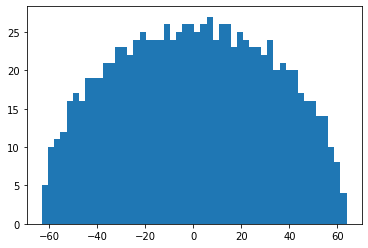

delta = 10.0


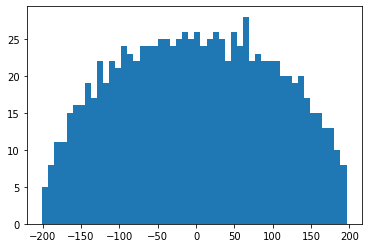

In [ ]:
# Generate the cards game dataset

def card_game_dataset(N, delta):

    S = np.random.choice([1., -1.], size=(N,1))
    W = np.random.randn(N, N) * np.sqrt(delta)
    W = np.tril(W) + np.tril(W, -1).T
    Y = S @ S.T / np.sqrt(N) + W
    return S, Y

# Plot the spectrum for N = 1000, delta = {.001, .01, .1, 10, 100}

N = 1000

deltas = np.logspace(-3, 1, 5)

for delta in deltas:

    print(f'delta = {delta}')
    _, Y = card_game_dataset(N, delta)
    eval, evec = np.linalg.eigh(Y)
    plt.hist(eval, bins=50)
    plt.show();

In [ ]:
# Compute the alignment Q of the spectral estimator with the vector S

import scipy.linalg as sla

deltas = np.linspace(0, 3, 20)

Q = []
exps = 5

for delta in deltas:

    q = np.zeros(exps)

    for exp in range(exps):
        S, Y = card_game_dataset(N, delta)
        max_eval, max_evec = sla.eigh(Y, eigvals=(len(Y)-1, len(Y)-1))
        q[exp] = np.absolute((np.sign(max_evec) * S).mean())

    Q.append(q.mean())

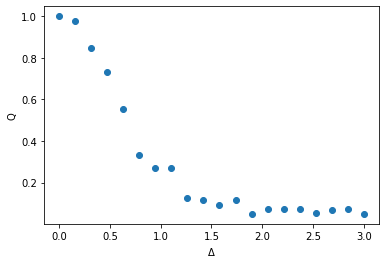

In [ ]:
# Plot Q vs delta

plt.plot(deltas, Q, 'o')
plt.xlabel('$\Delta$')
plt.ylabel('Q');